In [1]:
# ibraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
RANDOM_STATE = 42


# TASK 5 · Sales Prediction Using Python

## Objective
Predict product sales from advertising expenditure across **TV, Radio and Newspaper** channels.


### Dataset

The notebook checks for a local Advertising CSV first and then tries a public copy.


In [2]:
def load_advertising_dataset():
    local_candidates = [
        Path("Advertising.csv"),
        Path("advertising.csv")
    ]

    for path in local_candidates:
        if path.exists():
            print(f"Loading local dataset: {path}")
            return pd.read_csv(path)

    urls = [
        "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv",
        "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Advertising.csv"
    ]

    last_error = None
    for url in urls:
        try:
            print("Attempting to load the Advertising dataset...")
            return pd.read_csv(url)
        except Exception as exc:
            last_error = exc

    raise FileNotFoundError(
        "Advertising dataset not found. Put 'Advertising.csv' "
        "in the notebook folder and run this cell again."
    ) from last_error

sales_df = load_advertising_dataset()

sales_df.columns = [str(c).strip() for c in sales_df.columns]

rename_map = {}
for col in sales_df.columns:
    key = col.lower()
    if key == "tv":
        rename_map[col] = "TV"
    elif key == "radio":
        rename_map[col] = "Radio"
    elif key == "newspaper":
        rename_map[col] = "Newspaper"
    elif key == "sales":
        rename_map[col] = "Sales"

sales_df = sales_df.rename(columns=rename_map)
sales_df = sales_df.loc[
    :,
    ~sales_df.columns.str.lower().str.startswith("unnamed")
]

required = {"TV", "Radio", "Newspaper", "Sales"}
missing = required - set(sales_df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

display(sales_df.head())

Loading local dataset: Advertising.csv


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## 5.1 Data Loading and EDA


In [3]:
print("Dataset shape:", sales_df.shape)

print("\nData types:")
print(sales_df.dtypes)

print("\nMissing values:")
display(sales_df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", sales_df.duplicated().sum())

print("\nDescriptive statistics:")
display(sales_df.describe().round(2))

Dataset shape: (200, 4)

Data types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing values:


,Missing Values
TV,0
Radio,0
Newspaper,0
Sales,0



Duplicate rows: 0

Descriptive statistics:


,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,15.13
std,85.85,14.85,21.78,5.28
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,11.00
50%,149.75,22.90,25.75,16.00
75%,218.82,36.52,45.10,19.05
max,296.40,49.60,114.00,27.00


## 5.2 Pairplot of All Features


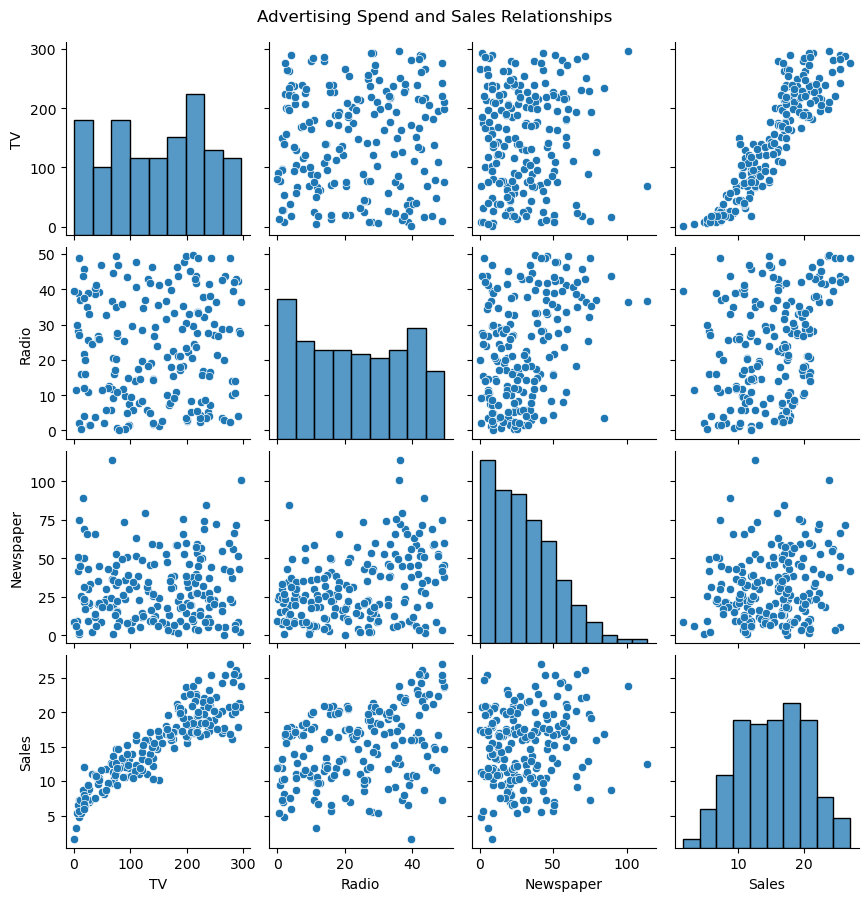

In [4]:
sns.pairplot(sales_df, height=2.2)
plt.suptitle("Advertising Spend and Sales Relationships", y=1.02)
plt.show()

## 5.3 Individual Scatter Plots


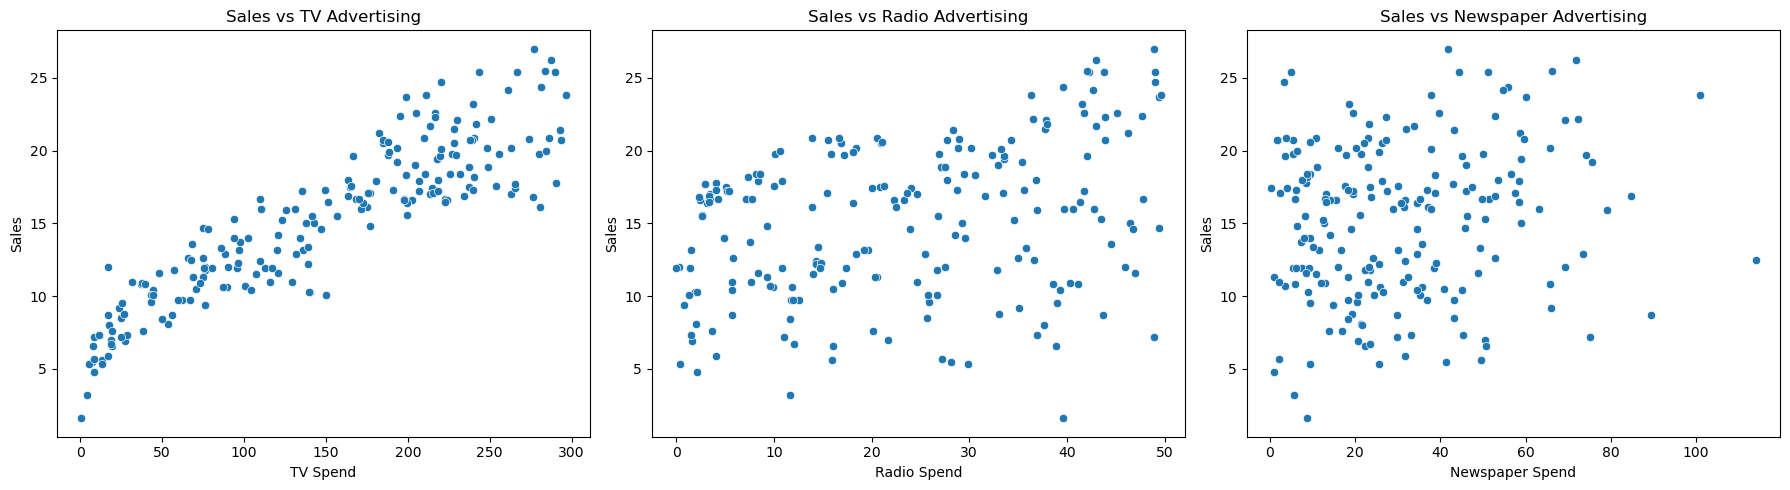

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, channel in zip(
    axes,
    ["TV", "Radio", "Newspaper"]
):
    sns.scatterplot(
        data=sales_df,
        x=channel,
        y="Sales",
        ax=ax
    )
    ax.set_title(f"Sales vs {channel} Advertising")
    ax.set_xlabel(f"{channel} Spend")
    ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()

## 5.4 Correlation Matrix and Heatmap


,TV,Radio,Newspaper,Sales
TV,1.000,0.055,0.057,0.901
Radio,0.055,1.000,0.354,0.350
Newspaper,0.057,0.354,1.000,0.158
Sales,0.901,0.350,0.158,1.000


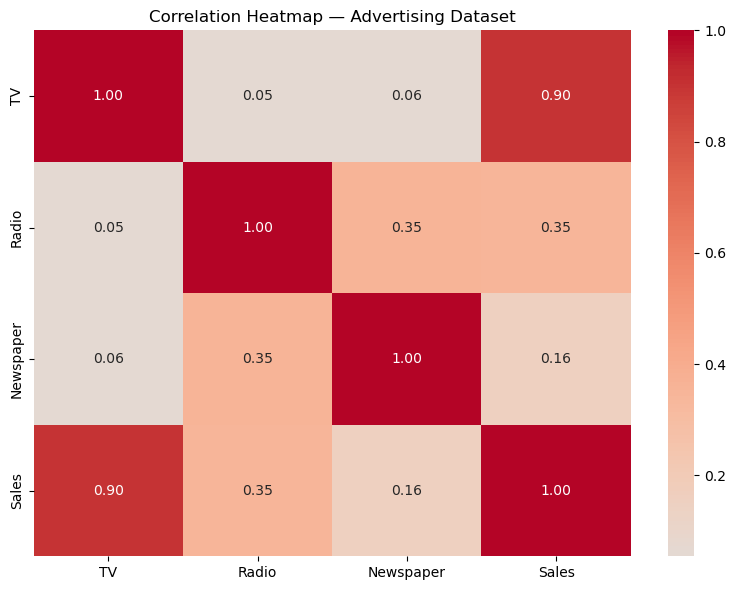

In [6]:
correlation_matrix = sales_df[
    ["TV", "Radio", "Newspaper", "Sales"]
].corr()

display(correlation_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap — Advertising Dataset")
plt.tight_layout()
plt.show()

## 5.5 Train/Test Split


In [7]:
X_sales = sales_df[["TV", "Radio", "Newspaper"]]
y_sales = sales_df["Sales"]

X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(
    X_sales,
    y_sales,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train_sales))
print("Testing samples:", len(X_test_sales))

Training samples: 160
Testing samples: 40


## 5.6 Train Linear Regression and Random Forest


In [8]:
sales_linear_model = LinearRegression()
sales_linear_model.fit(X_train_sales, y_train_sales)

sales_rf_model = RandomForestRegressor(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
sales_rf_model.fit(X_train_sales, y_train_sales)

sales_linear_pred = sales_linear_model.predict(X_test_sales)
sales_rf_pred = sales_rf_model.predict(X_test_sales)

print("Both sales prediction models trained successfully.")

Both sales prediction models trained successfully.


## 5.7 Evaluate Models — MAE, RMSE and R²


In [9]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

In [10]:
sales_results = pd.DataFrame({
    "Linear Regression": regression_metrics(y_test_sales, sales_linear_pred),
    "Random Forest": regression_metrics(y_test_sales, sales_rf_pred)
}).T

display(sales_results.sort_values("RMSE"))

,MAE,RMSE,R²
Random Forest,0.906794,1.183701,0.954657
Linear Regression,1.274826,1.705215,0.905901


## 5.8 Best Model and Residual Plot


In [11]:
best_sales_model_name = sales_results["RMSE"].idxmin()

if best_sales_model_name == "Linear Regression":
    best_sales_predictions = sales_linear_pred
else:
    best_sales_predictions = sales_rf_pred

print(f"Best performing sales model: {best_sales_model_name}")
print("Selection criterion: lowest test-set RMSE.")

Best performing sales model: Random Forest
Selection criterion: lowest test-set RMSE.


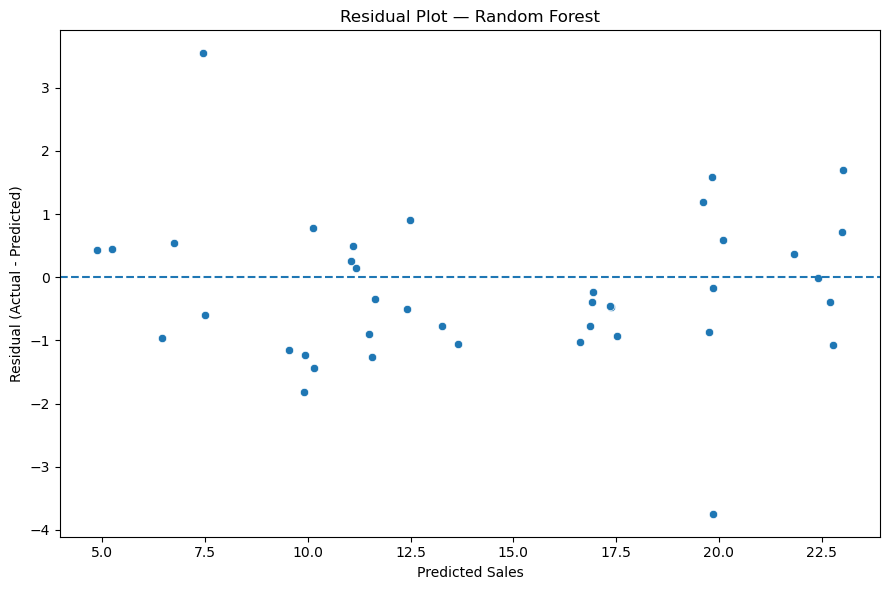

A strong residual plot should show points scattered around zero without a strong curve or systematic pattern.


In [12]:
sales_residuals = y_test_sales.to_numpy() - best_sales_predictions

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=best_sales_predictions,
    y=sales_residuals
)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot — {best_sales_model_name}")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

print(
    "A strong residual plot should show points scattered around zero "
    "without a strong curve or systematic pattern."
)

## 5.9 Advertising Channel Impact


Linear Regression coefficients:


,Coefficient
Radio,0.100945
TV,0.054509
Newspaper,0.004337


Random Forest feature importance:


,Importance
TV,0.842940
Radio,0.138203
Newspaper,0.018856


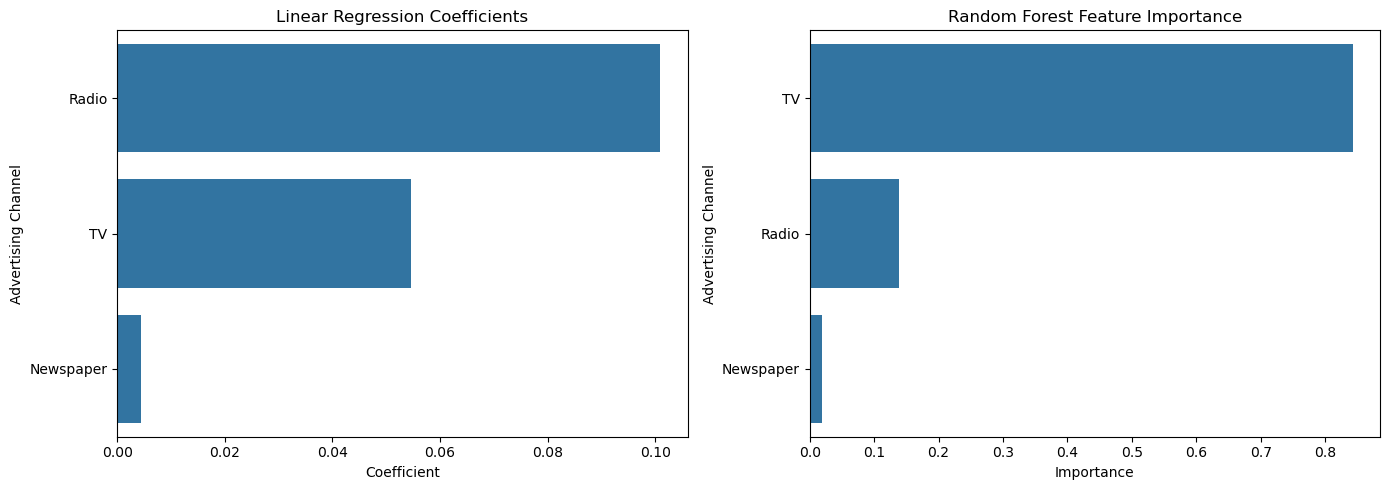

Highest absolute Linear Regression coefficient: Radio
Highest Random Forest importance: TV


In [13]:
linear_coefficients = pd.Series(
    sales_linear_model.coef_,
    index=X_sales.columns
).sort_values(key=np.abs, ascending=False)

rf_importance_sales = pd.Series(
    sales_rf_model.feature_importances_,
    index=X_sales.columns
).sort_values(ascending=False)

print("Linear Regression coefficients:")
display(linear_coefficients.to_frame("Coefficient"))

print("Random Forest feature importance:")
display(rf_importance_sales.to_frame("Importance"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=linear_coefficients.values,
    y=linear_coefficients.index,
    ax=axes[0]
)
axes[0].set_title("Linear Regression Coefficients")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Advertising Channel")

sns.barplot(
    x=rf_importance_sales.values,
    y=rf_importance_sales.index,
    ax=axes[1]
)
axes[1].set_title("Random Forest Feature Importance")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Advertising Channel")

plt.tight_layout()
plt.show()

print("Highest absolute Linear Regression coefficient:",
      linear_coefficients.index[0])
print("Highest Random Forest importance:",
      rf_importance_sales.index[0])

## 5.10 Interpretation

The coefficients and feature importance show which advertising channel is most useful for predicting sales.
